In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 

In [110]:
with open("../data/02-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/02-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)
with open("../data/02-result/trials_df.pkl","rb") as f:
    trials_df =pickle.load(f)
with open("../data/02-result/indications_df.pkl","rb") as f:
    indications_df =pickle.load(f)
with open("../data/01-result/embeddings_df.pkl","rb") as f:
    embeddings_df =pickle.load(f)
with open("../data/01-result/fingerprints_df.pkl","rb") as f:
    fingerprints_df =pickle.load(f)

# Overview

In [111]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (2314, 95)
Diseases:
    (168, 83)
Trials:
    (7023, 11)
Indications:
    (7637, 10)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1547, 101)


In [112]:
indications_df["overall_success"].value_counts()

overall_success
False    2184
True     1052
Name: count, dtype: Int64

# Missing values before merging

In [113]:
# drugs_df.isnull().sum().sort_values(ascending=False)
drugs_df = drugs_df.dropna(subset=["targets"])
drugs_df = drugs_df[drugs_df.drug_path_str.str.len()>0]
drugs_df = drugs_df[~drugs_df["biotherapeutic"].astype(bool)]
drugs_df = drugs_df[~drugs_df["withdrawn_flag"]]
drugs_df = drugs_df.drop(columns=["max_phase","helm_notation", "first_approval", "usan_year", "usan_stem_definition",
                                  "standard_inchi_key", "standard_inchi", "canonical_smiles", "full_molformula",
                                  "withdrawn_flag", "black_box_warning", "first_in_class", "molecule_type",
                                  "biotherapeutic", "targets", "drug_path_str"])

diseases_df  = diseases_df[diseases_df.disease_path_str.str.len()>0]
diseases_df = diseases_df.drop(columns=["description", "associatedTargets", "phenotypes",
                                         "disease_targets", "disease_path_str"])


indications_df = indications_df.dropna(subset=["overall_success"])

In [114]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (831, 79)
Diseases:
    (167, 78)
Trials:
    (7023, 11)
Indications:
    (3236, 10)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1547, 101)


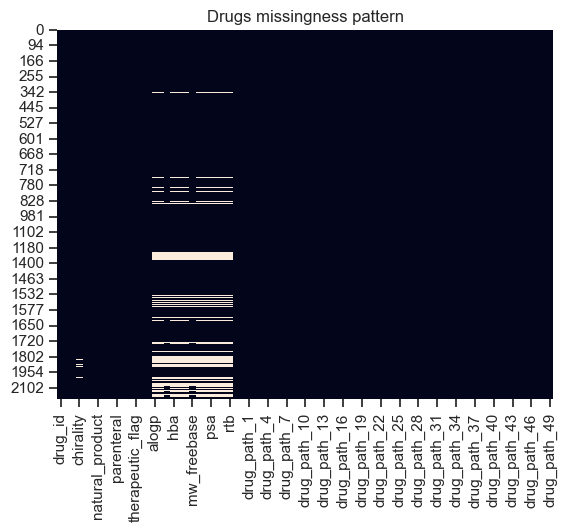

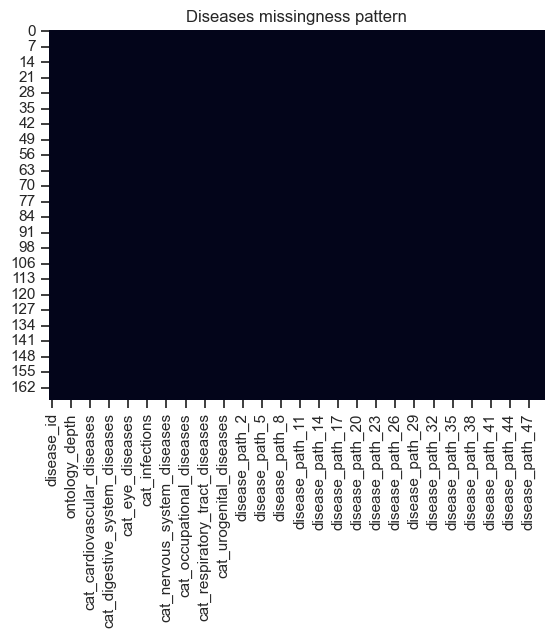

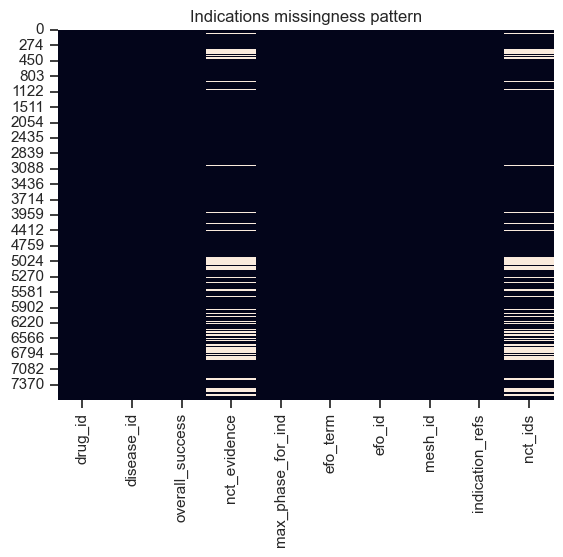

In [115]:
sns.heatmap(drugs_df.isnull(), cbar=False)
plt.title("Drugs missingness pattern")
plt.show()
sns.heatmap(diseases_df.isnull(), cbar=False)
plt.title("Diseases missingness pattern")
plt.show()
sns.heatmap(indications_df.isnull(), cbar=False)
plt.title("Indications missingness pattern")
plt.show()

In [116]:
encoded = pd.get_dummies(drugs_df["chirality"], drop_first=True, dummy_na=True, prefix="chirality_").astype(int) # "achiral" as baseline
drugs_df = drugs_df.drop(columns=["chirality"]).join(encoded)

should_be_num_features = ["dosed_ingredient", "alogp","full_mwt",
             "mw_freebase", "np_likeness_score", "psa", "qed_weighted"]
for col in should_be_num_features:
    drugs_df[col] = pd.to_numeric(drugs_df[col], errors="coerce")

drugs_df["ro3_pass"] = drugs_df["ro3_pass"].str.lower().map({"y": 1, "n":0})

knn_imp = KNNImputer(n_neighbors=5)
num_features = drugs_df.select_dtypes(include=np.number).columns
drugs_df[num_features] = knn_imp.fit_transform(drugs_df[num_features])

# Merge all

In [117]:
drugs_df = drugs_df.merge(fingerprints_df, on="drug_id")
diseases_df["disease_id"] = diseases_df["disease_id"].str.replace("_",":")
embeddings_df["disease_id"] = embeddings_df["disease_id"].str.replace("_",":")
merged_df = (indications_df[["drug_id", "disease_id", "overall_success"]]
             .merge(drugs_df, on="drug_id")
             .merge(diseases_df, on="disease_id")
             .merge(embeddings_df[["drug_id", "disease_id","name_similarity"]], on =["drug_id", "disease_id"]))

For each combination drug-disease, add Jaccard similarity between their pathway lists.

**NOTE:** `drug_path_...` and `disease_path_...` are correspining TF-IDF embeddings obtained from pathway lists of drugs and dieseases **separately**. So TF-IDF capture pathway similarities among all drugs and among all diseases separately, whereas Jaccard similarity compares pathway similarity of a pair drug-disease.

In [118]:
for i, comb in merged_df.iterrows():
    drug_path = set(comb["drug_pathways"])
    disease_path = set(comb["disease_pathways"])
    merged_df.loc[i,"path_similarity"] = len(drug_path & disease_path) / len(drug_path | disease_path)

In [119]:
merged_df = (merged_df[["drug_id","disease_id", "drug_name", "disease_name"]]
             .join(merged_df.select_dtypes(exclude=["object"])))
merged_df = merged_df.rename(columns={"overall_success" : "success"})
merged_df = merged_df.dropna(subset=["success"])
merged_df

,drug_id,disease_id,drug_name,disease_name,success,chemical_probe,dosed_ingredient,inorganic_flag,natural_product,oral,...,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity,path_similarity
0,CHEMBL1467,EFO:0000574,allopurinol,lymphoma,True,0.0,True,0.0,1.0,True,...,0.051397,0.092460,-0.103163,-0.106226,-0.067319,0.071138,0.046087,0.006378,0.075028,0.000000
1,CHEMBL514800,EFO:0000274,apremilast,atopic eczema,False,0.0,True,0.0,1.0,True,...,-0.006186,-0.001279,0.085222,0.029124,-0.073109,0.004507,0.069959,0.057522,0.094691,0.115385
2,CHEMBL1370,EFO:0005854,budesonide,allergic rhinitis,True,0.0,True,0.0,1.0,True,...,0.006938,-0.110494,0.051966,-0.002489,0.059104,0.058223,-0.025742,0.012585,0.249712,0.375000
3,CHEMBL118,EFO:0000685,celecoxib,rheumatoid arthritis,True,0.0,True,0.0,0.0,True,...,-0.037634,-0.012053,-0.039019,0.027868,-0.010846,0.014261,-0.035960,-0.025463,0.221504,0.025641
4,CHEMBL1607273,EFO:0005854,cetirizine hydrochloride,allergic rhinitis,True,0.0,True,0.0,0.0,True,...,0.006938,-0.110494,0.051966,-0.002489,0.059104,0.058223,-0.025742,0.012585,0.144043,0.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,CHEMBL5315122,EFO:0001378,bortezomib d-mannitol,multiple myeloma,True,0.0,True,0.0,0.0,False,...,0.037799,-0.000593,0.033429,-0.032749,-0.078326,0.048252,0.016062,-0.021547,0.373565,0.034335
1294,CHEMBL5315122,EFO:0001378,bortezomib d-mannitol,multiple myeloma,True,0.0,True,0.0,0.0,False,...,0.037799,-0.000593,0.033429,-0.032749,-0.078326,0.048252,0.016062,-0.021547,0.373565,0.034335
1295,CHEMBL5315122,EFO:1001469,bortezomib d-mannitol,Mantle cell lymphoma,True,0.0,True,0.0,0.0,False,...,-0.009348,0.015483,0.024776,0.002845,-0.041079,0.009393,0.022485,-0.000040,0.106201,0.463087
1296,CHEMBL6068328,EFO:0007160,eltrombopag choline,autoimmune thrombocytopenic purpura,True,0.0,True,0.0,0.0,True,...,0.057472,0.177177,0.040324,0.048782,0.070714,-0.021981,-0.064578,-0.021980,0.181563,0.027027


In [120]:
print(f"Merged data:\n  {merged_df.shape}")
merged_df["success"].value_counts()

Merged data:
  (1298, 259)


success
False    741
True     557
Name: count, dtype: Int64

# Remove invariant columns

In [121]:
num_col_unique = merged_df.select_dtypes(include='number').nunique()
merged_df = merged_df.drop(columns = num_col_unique.index[num_col_unique == 1])

# Correlations and distributions

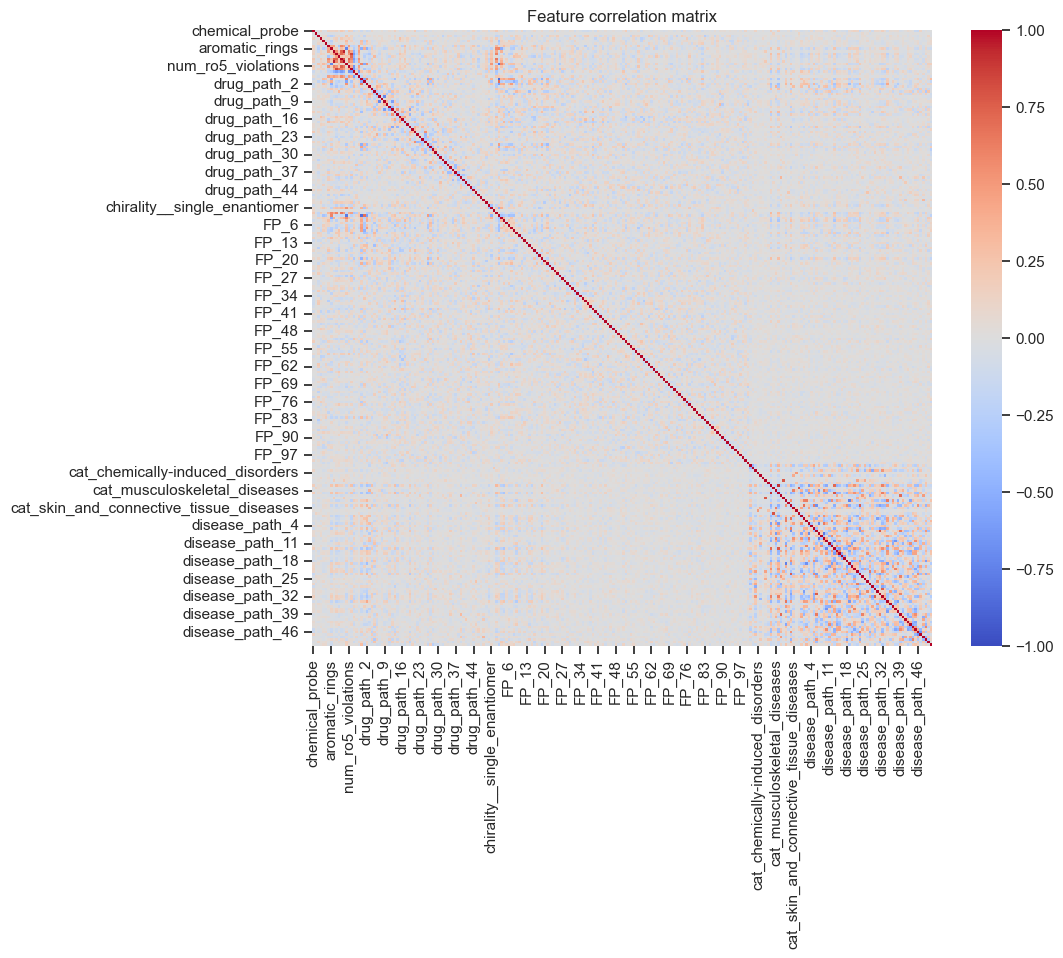

In [122]:
# don't consider some metrics
corr = (merged_df
        .select_dtypes(include=np.number)
        .corr())
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

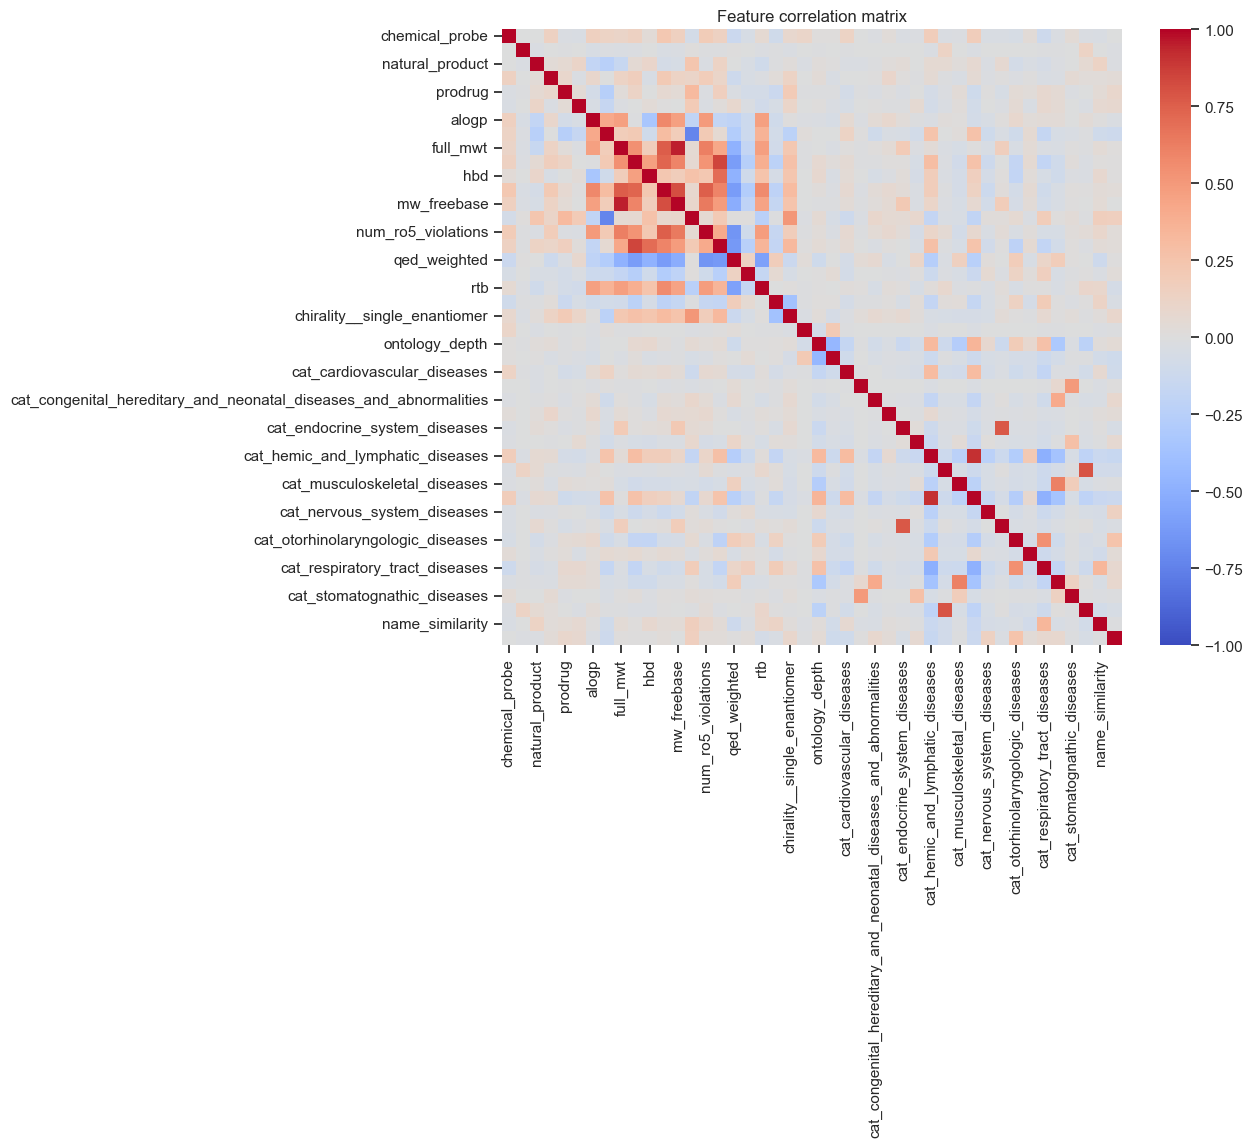

In [123]:
# close up for metrics with direct meaning
prefix_not_interpretable = ("FP", "drug_path", "disease_path")
merged_df_short = (merged_df
                .loc[:,~merged_df.columns.str.startswith(prefix_not_interpretable)]
                .select_dtypes(include=np.number))
corr = merged_df_short.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

In [124]:
# Can be too long
# sns.set_theme(style="ticks")
# sns.pairplot(merged_df_short.join(merged_df["success"]), hue="success")

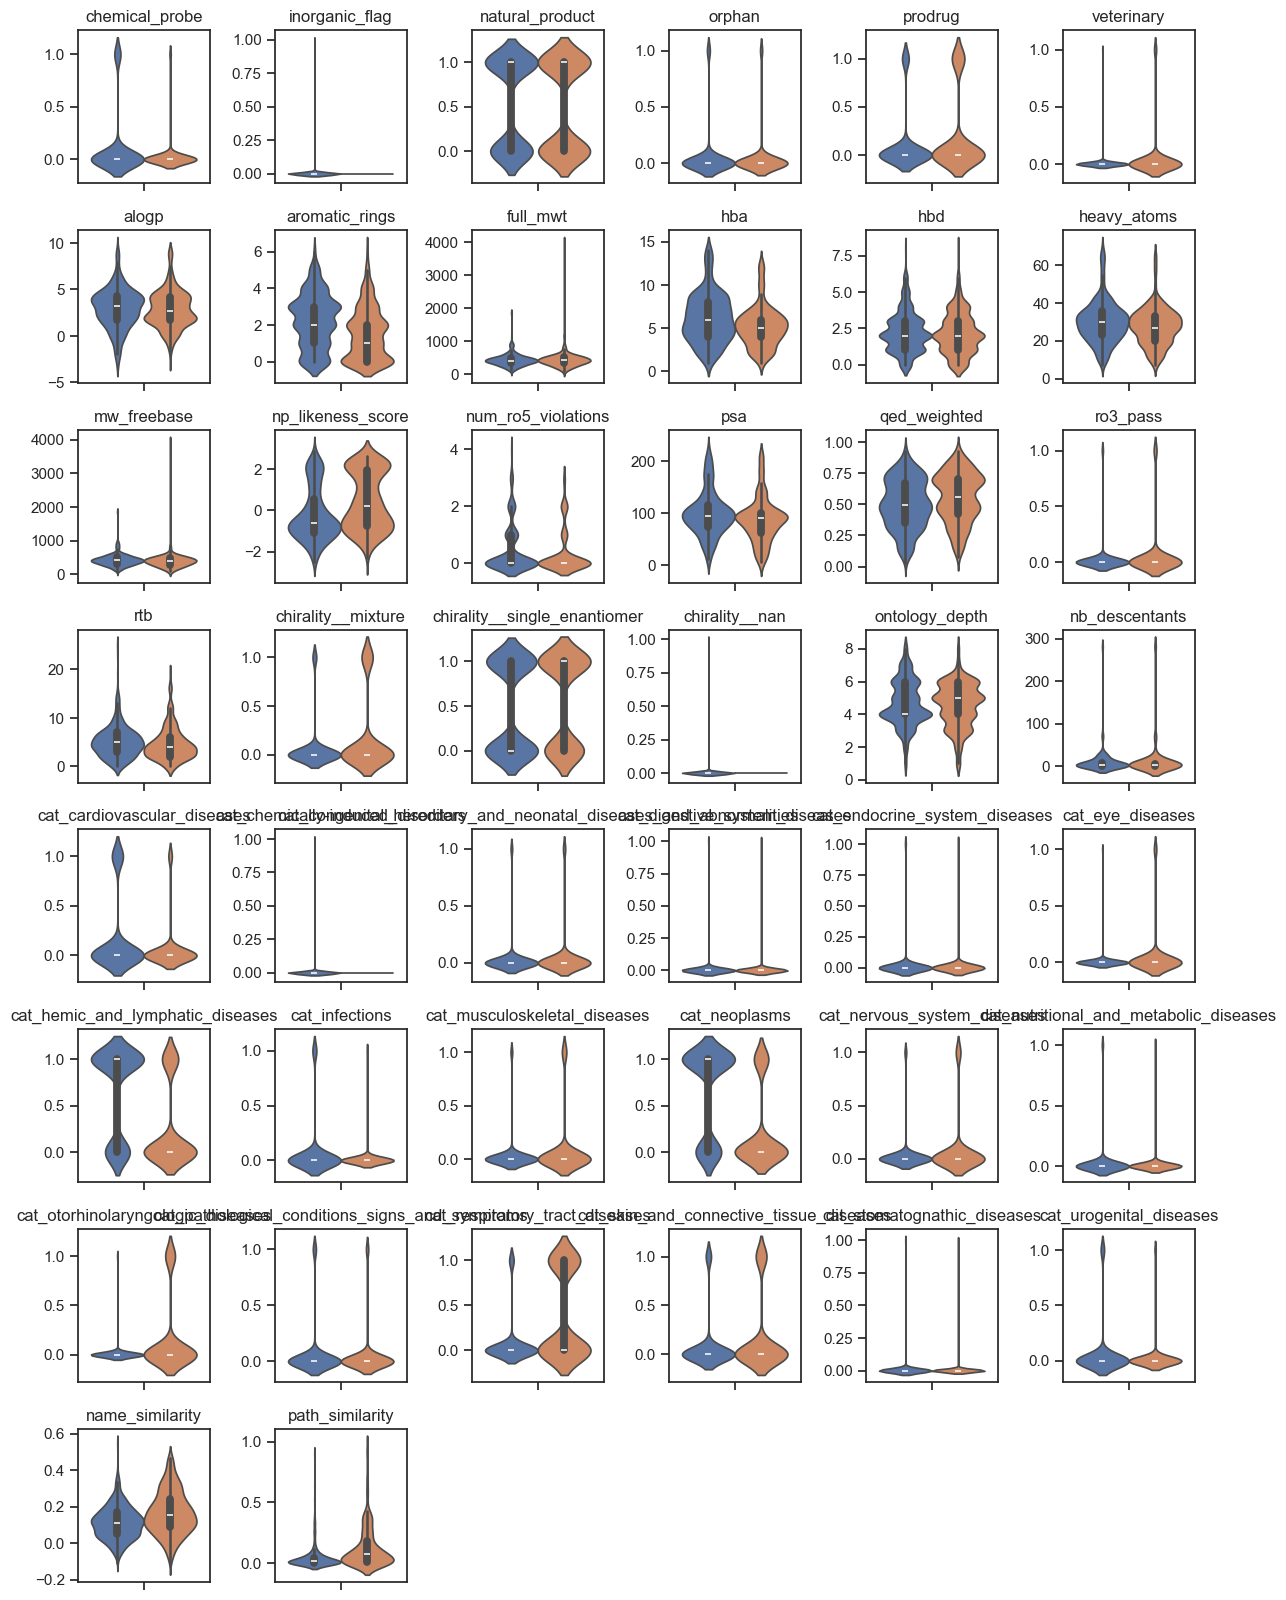

In [125]:
num_features = merged_df.select_dtypes(include=np.number).columns

n_cols = 6  # number of plots per row
n_rows = (len(num_features) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(num_features[~num_features.str.startswith(prefix_not_interpretable)]):
    sns.violinplot(y=merged_df[col], ax = axes[i], hue=merged_df["success"]);
    axes[i].set_title(col)
    axes[i].set_ylabel(None)
    axes[i].get_legend().remove()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Dimension reduction

In [126]:
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]
X_scaled = StandardScaler().fit_transform(X) # TODO: or don't scale for UMAP and tSNE?

def plot_dim_reduction(X, y, model_name="", prefix=None):
    plt.figure()
    for label in np.unique(y):
        plt.scatter(X[y == label, 0], X[y == label, 1],
                    label= "success" if label else "fail", alpha=.5)
    if prefix is None: prefix = model_name
    plt.xlabel(prefix+"1")
    plt.ylabel(prefix+"2")
    plt.title(model_name)
    plt.legend()
    plt.grid(True)
    plt.show()

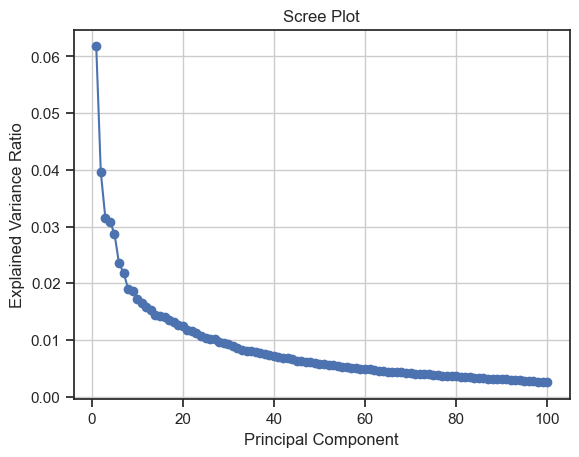

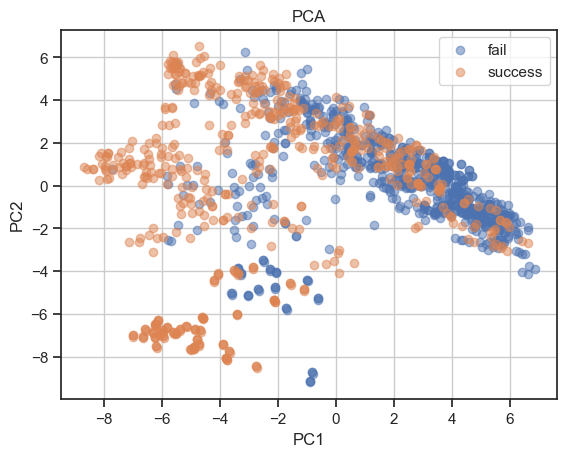

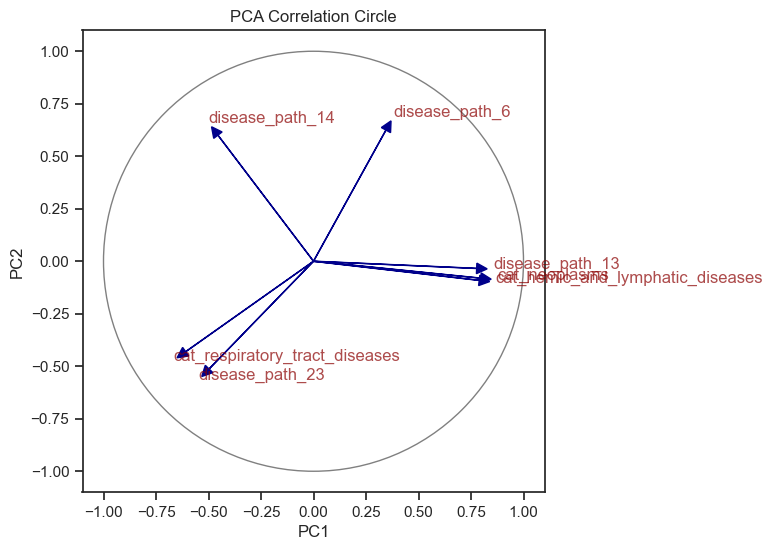

In [134]:
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

plot_dim_reduction(X_pca, y,"PCA","PC")

# Correlation circle
threshold = 0.7

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
fig, ax = plt.subplots(figsize=(6,6))
circle = plt.Circle((0,0),1,color='gray',fill=False)
ax.add_artist(circle)
for i, var in enumerate(X.columns):
    length = np.sqrt(loadings[i,0]**2 + loadings[i,1]**2)
    if length > threshold:
        ax.arrow(0,0,loadings[i,0],loadings[i,1],head_width=0.05,head_length=0.05,fc='darkblue',ec='darkblue')
        ax.text(loadings[i,0]*1.1, loadings[i,1]*1.1, var, color='darkred', alpha=0.7)
ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)
ax.set_aspect('equal')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Correlation Circle')
plt.show()


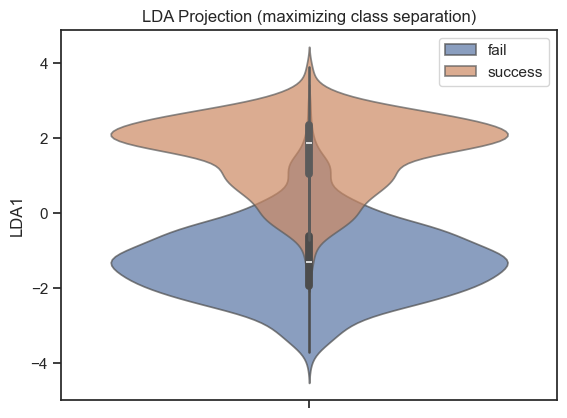

Explained variance ratio: [1.]


In [128]:
lda = LinearDiscriminantAnalysis(n_components=1)  # NOTE: n_components cannot be larger than min(n_features, n_classes - 1)
X_lda = lda.fit_transform(X_scaled, y)
plt.figure()
# sns.violinplot(data=pd.DataFrame({"LDA1": X_lda.flat, "success" : y}), y="LDA1", label="success")
for label in np.unique(y):
        sns.violinplot(X_lda[y == label, 0], alpha=0.7, label="success" if label else "fail")
plt.ylabel("LDA1")
plt.title("LDA Projection (maximizing class separation)")
plt.legend()
plt.show()

print("Explained variance ratio:", lda.explained_variance_ratio_)

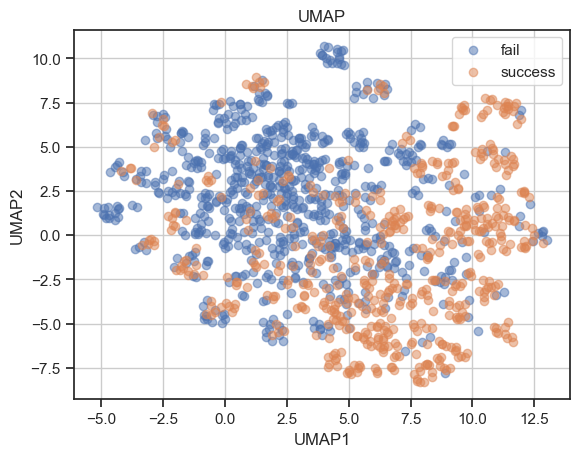

In [129]:
umap = UMAP(n_neighbors=20,min_dist=1,metric='correlation')
X_umap = umap.fit_transform(X_scaled) 
plot_dim_reduction(X_umap, y, "UMAP")

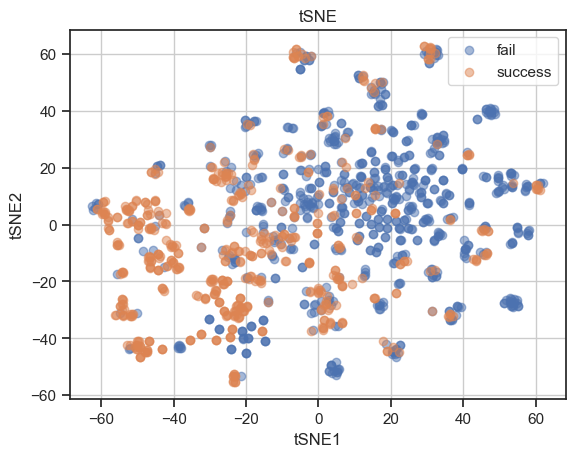

In [130]:
tsne = TSNE(n_components=2, perplexity=20)
X_tsne = tsne.fit_transform(X_scaled)
plot_dim_reduction(X_tsne, y, "tSNE")

# Save results

In [131]:
with open("../data/03-result/drugs_df.pkl","wb") as f:
    pickle.dump(drugs_df,f)
with open("../data/03-result/diseases_df.pkl","wb") as f:
    pickle.dump(diseases_df,f)
with open("../data/03-result/trials_df.pkl","wb") as f:
    pickle.dump(trials_df,f)
with open("../data/03-result/indications_df.pkl","wb") as f:
    pickle.dump(indications_df,f)
with open("../data/03-result/merged_df.pkl","wb") as f:
    pickle.dump(merged_df,f)